# Tugas Praktikum 1: Scraping & Eksplorasi Data (EDA)
**Mata Kuliah**: Data Mining  
**Topik**: Analysis of Global Remote Job Listings & Tech Stack Demand  
**Nama**: Muhamad Nafi Mulyo  
**NRP**: 5054251005  

---
## Deskripsi Singkat
Praktikum ini bertujuan untuk mengumpulkan data lowongan kerja remote global dan melakukan eksplorasi data (*Exploratory Data Analysis / EDA*). Analisis mencakup *Feature Engineering* (pengelompokan peran kerja, tingkat seniority, dan ekstraksi tech stack), identifikasi tipe atribut, statistik deskriptif, penanganan missing values & outliers, serta visualisasi insight.
---


## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import re
import time
from datetime import datetime
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
print("Library ready.")


Library ready.


## 2. Scraping Data

Pengambilan data dilakukan via `requests` dari REST API publik portal lowongan kerja remote (*Arbeitnow* & *Remotive*). Hasil mentah disimpan ke file `remote_jobs_raw.csv`.


In [2]:
jobs = []

# Fetch dari Arbeitnow API (page 1 - 15)
for page in range(1, 16):
    url = f"https://www.arbeitnow.com/api/job-board-api?page={page}"
    res = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=10)
    if res.status_code == 200:
        data = res.json().get('data', [])
        if not data:
            break
        for item in data:
            raw_tags = item.get('tags', [])
            tag_list = raw_tags if isinstance(raw_tags, list) else []
            raw_types = item.get('job_types', [])
            type_str = ', '.join(raw_types) if isinstance(raw_types, list) else str(raw_types)
            
            ts = item.get('created_at')
            date_str = datetime.fromtimestamp(ts).strftime('%Y-%m-%d') if isinstance(ts, (int, float)) else str(ts)
            
            jobs.append({
                'job_id': item.get('slug', ''),
                'title': item.get('title', '').strip(),
                'company_name': item.get('company_name', '').strip(),
                'location': item.get('location', '').strip(),
                'is_remote': item.get('remote', True),
                'job_type': type_str if type_str else 'Full Time',
                'tags': ', '.join(tag_list),
                'tags_count': len(tag_list),
                'posted_date': date_str,
                'source': 'Arbeitnow',
                'source_url': item.get('url', '')
            })
        time.sleep(0.1)

# Fetch dari Remotive API
try:
    res = requests.get('https://remotive.com/api/remote-jobs', headers={'User-Agent': 'Mozilla/5.0'}, timeout=10)
    if res.status_code == 200:
        for item in res.json().get('jobs', []):
            tag_list = item.get('tags', []) if isinstance(item.get('tags'), list) else []
            jobs.append({
                'job_id': f"remotive-{item.get('id')}",
                'title': item.get('title', '').strip(),
                'company_name': item.get('company_name', '').strip(),
                'location': item.get('candidate_required_location', '').strip(),
                'is_remote': True,
                'job_type': item.get('job_type', 'Full Time'),
                'tags': ', '.join(tag_list),
                'tags_count': len(tag_list),
                'posted_date': item.get('publication_date', '')[:10],
                'source': 'Remotive',
                'source_url': item.get('url', '')
            })
except Exception as e:
    print(f"Remotive error: {e}")

df_raw = pd.DataFrame(jobs)
df_raw.to_csv('remote_jobs_raw.csv', index=False, encoding='utf-8')
print(f"Scraping selesai. Total: {len(df_raw)} baris, {len(df_raw.columns)} kolom.")


Scraping selesai. Total: 1816 baris, 11 kolom.


## 3. Import Dataset & Feature Engineering

Pada tahap ini, kita membaca data mentah dan membuat 3 fitur turunan baru:
1. `seniority`: Tingkat pengalaman (*Senior/Lead*, *Mid-Level*, *Junior/Entry*, *Student/Intern*).
2. `role_category`: Kategori peran kerja (*Software Engineering*, *Data & AI*, *DevOps & Cloud*, *Product & Design*, *Business & Sales*, *Other Services*).
3. `tech_stack_clean`: Ekstraksi spesifik nama bahasa pemrograman / tools teknis (*Python, React, AWS, SQL, Go, dll*).


In [3]:
df = pd.read_csv('remote_jobs_raw.csv')

def get_seniority(title):
    t = str(title).lower()
    if any(k in t for k in ['student', 'werkstudent', 'intern', 'praktikant']):
        return 'Student / Intern'
    elif any(k in t for k in ['junior', 'entry', 'trainee', 'associate']):
        return 'Junior / Entry'
    elif any(k in t for k in ['senior', 'lead', 'principal', 'staff', 'head', 'chief', 'architect']):
        return 'Senior / Lead'
    else:
        return 'Mid-Level'

def get_role(row):
    text = f"{row['title']} {row['tags']}".lower()
    if any(k in text for k in ['data', 'analytics', 'machine learning', 'ai ', 'scientist', 'business intelligence']):
        return 'Data & AI'
    elif any(k in text for k in ['devops', 'cloud', 'infrastructure', 'sre', 'security', 'sysadmin', 'aws', 'docker']):
        return 'DevOps & Cloud'
    elif any(k in text for k in ['designer', 'ui', 'ux', 'product manager', 'product owner']):
        return 'Product & Design'
    elif any(k in text for k in ['developer', 'engineer', 'frontend', 'backend', 'fullstack', 'software', 'mobile', 'web', 'python', 'javascript', 'react']):
        return 'Software Engineering'
    elif any(k in text for k in ['sales', 'marketing', 'account', 'growth', 'finance', 'hr', 'recruiter']):
        return 'Business & Sales'
    else:
        return 'Other Services'

known_techs = ['Python', 'JavaScript', 'TypeScript', 'React', 'Node.js', 'Vue', 'Angular', 'Java', 'C++', 'C#', 'Go', 'Rust', 'SQL', 'PostgreSQL', 'Docker', 'Kubernetes', 'AWS', 'Azure', 'GCP', 'Linux', 'PHP', 'Ruby', 'Swift', 'Flutter']

def get_clean_techs(row):
    text = f"{row['title']} {row['tags']}"
    found = []
    for tech in known_techs:
        pattern = r'\b' + re.escape(tech) + r'\b'
        if re.search(pattern, text, re.IGNORECASE):
            found.append(tech)
    return ', '.join(found) if found else 'Unspecified'

df['seniority'] = df['title'].apply(get_seniority)
df['role_category'] = df.apply(get_role, axis=1)
df['tech_stack_clean'] = df.apply(get_clean_techs, axis=1)

df.head()


,job_id,title,company_name,location,is_remote,job_type,tags,tags_count,posted_date,source,source_url,seniority,role_category,tech_stack_clean
0,senior-backend-engineer-databases-pyroscope-ge...,Senior Backend Engineer - Databases Pyroscope ...,grafanalabs,NaN,False,Full Time,R&D : Databases,1,2026-09-14,Arbeitnow,https://www.arbeitnow.com/jobs/companies/grafa...,Senior / Lead,Data & AI,Unspecified
1,software-engineer-data-infrastructure-acquisit...,"Software Engineer, Data Infrastructure & Acqui...",speechify,Munich,False,Full Time,Global,1,2026-09-14,Arbeitnow,https://www.arbeitnow.com/jobs/companies/speec...,Mid-Level,Data & AI,Unspecified
2,senior-software-engineer-windows-desktop-appli...,"Senior Software Engineer, Windows/Desktop Appl...",speechify,Munich,False,Full Time,Global,1,2026-09-14,Arbeitnow,https://www.arbeitnow.com/jobs/companies/speec...,Senior / Lead,Software Engineering,Unspecified
3,senior-software-engineer-windows-desktop-appli...,"Senior Software Engineer, Windows/Desktop Appl...",speechify,Hamburg,False,Full Time,Global,1,2026-09-14,Arbeitnow,https://www.arbeitnow.com/jobs/companies/speec...,Senior / Lead,Software Engineering,Unspecified
4,senior-software-engineer-windows-desktop-appli...,"Senior Software Engineer, Windows/Desktop Appl...",speechify,Düsseldorf,False,Full Time,Global,1,2026-09-14,Arbeitnow,https://www.arbeitnow.com/jobs/companies/speec...,Senior / Lead,Software Engineering,Unspecified


In [4]:
print("Dimensi dataset:", df.shape)
print("\nTipe Data Kolom:")
print(df.dtypes)


Dimensi dataset: (1816, 14)

Tipe Data Kolom:
job_id                str
title                 str
company_name          str
location              str
is_remote            bool
job_type              str
tags                  str
tags_count          int64
posted_date           str
source                str
source_url            str
seniority             str
role_category         str
tech_stack_clean      str
dtype: object


### Identifikasi Tipe Atribut Dataset

| No | Nama Atribut | Tipe Data Python | Tipe Atribut Data Mining | Keterangan |
|:---|:---|:---|:---|:---|
| 1 | `job_id` | `object` | **Nominal** | ID/Slug unik lowongan |
| 2 | `title` | `object` | **Nominal** | Judul posisi pekerjaan |
| 3 | `company_name` | `object` | **Nominal** | Nama perusahaan |
| 4 | `location` | `object` | **Nominal** | Persyaratan lokasi |
| 5 | `is_remote` | `bool` | **Nominal (Biner)** | Status remote |
| 6 | `job_type` | `object` | **Nominal** | Tipe komitmen kerja |
| 7 | `tags` | `object` | **Nominal (Text)** | Tag mentah lowongan |
| 8 | `tags_count` | `int64` | **Numerik Diskrit** | Jumlah tag/skill |
| 9 | `posted_date` | `object` | **Ordinal (Waktu)** | Tanggal publikasi |
| 10 | `source` | `object` | **Nominal** | Sumber platform |
| 11 | `seniority` | `object` | **Ordinal** | Tingkat pengalaman |
| 12 | `role_category` | `object` | **Nominal** | Kategori bidang pekerjaan |
| 13 | `tech_stack_clean`| `object` | **Nominal (Text List)** | Skill & tools teknis murni |


## 4. Analisis Statistik dan Kualitas Data

In [5]:
# Perhitungan statistik deskriptif untuk atribut numerik
mean_val = df['tags_count'].mean()
median_val = df['tags_count'].median()
mode_val = df['tags_count'].mode()[0]
std_val = df['tags_count'].std()

print("=== STATISTIK DESKRIPTIF (tags_count) ===")
print(f"Mean   : {mean_val:.2f}")
print(f"Median : {median_val:.2f}")
print(f"Modus  : {mode_val}")
print(f"Std Dev: {std_val:.2f}")
print(f"Min-Max: {df['tags_count'].min()} - {df['tags_count'].max()}")


=== STATISTIK DESKRIPTIF (tags_count) ===
Mean   : 2.43
Median : 1.00
Modus  : 1
Std Dev: 4.26
Min-Max: 0 - 53


In [6]:
# Identifikasi & Handling Missing Values
print("=== JUMLAH MISSING VALUES ===")
print(df.isnull().sum()[df.isnull().sum() > 0])

df['location'] = df['location'].fillna('Unspecified / Worldwide')
df['tags'] = df['tags'].fillna('No tags')

# Outlier Detection pada tags_count (Metode IQR)
Q1 = df['tags_count'].quantile(0.25)
Q3 = df['tags_count'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers = df[df['tags_count'] > upper_bound]
print(f"\nIQR: {IQR}, Upper Bound: {upper_bound}")
print(f"Jumlah Outlier tags_count: {len(outliers)} baris ({len(outliers)/len(df)*100:.2f}%)")


=== JUMLAH MISSING VALUES ===
location     85
tags        252
dtype: int64

IQR: 1.0, Upper Bound: 3.5
Jumlah Outlier tags_count: 300 baris (16.52%)


## 5. Visualisasi Data & Interpretasi Insight

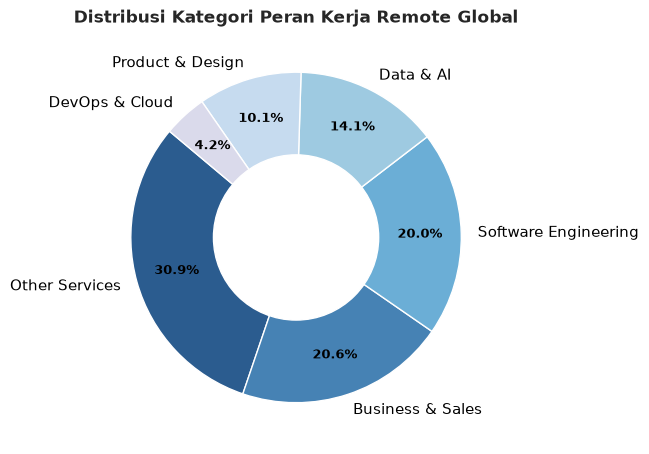

In [7]:
# Grafik 1: Distribusi Kategori Peran Kerja Remote (Donut Chart)
role_counts = df['role_category'].value_counts()

fig, ax = plt.subplots(figsize=(6.5, 6.5))
colors = ['#2b5c8f', '#4682b4', '#6baed6', '#9ecae1', '#c6dbef', '#dadaeb']
wedges, texts, autotexts = ax.pie(role_counts, labels=role_counts.index, autopct='%1.1f%%',
                                  startangle=140, colors=colors, pctdistance=0.75,
                                  textprops=dict(color="black"))
plt.setp(autotexts, size=9, weight="bold")
centre_circle = plt.Circle((0,0), 0.50, fc='white')
fig.gca().add_artist(centre_circle)

ax.set_title("Distribusi Kategori Peran Kerja Remote Global", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


**Insight Grafik 1**:  
Bidang *Software Engineering* dan *Business/Sales* memegang porsi terbesar dalam pasar kerja remote global, disusul oleh bidang *Data & AI* dan *Product & Design*.


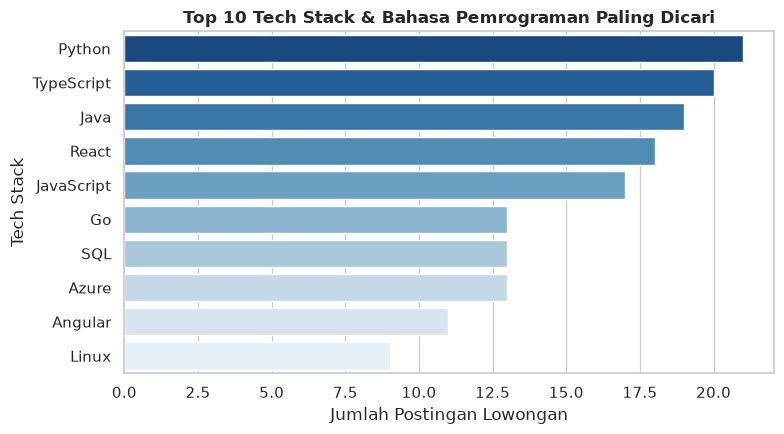

In [8]:
# Grafik 2: Top 10 Tech Stack & Bahasa Pemrograman Paling Dicari
all_techs = []
for t in df['tech_stack_clean']:
    if t != 'Unspecified':
        all_techs.extend([x.strip() for x in t.split(',')])

top_tech_df = pd.DataFrame(Counter(all_techs).most_common(10), columns=['Tech Stack', 'Frequency'])

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(data=top_tech_df, x='Frequency', y='Tech Stack', palette='Blues_r', ax=ax)
ax.set_title("Top 10 Tech Stack & Bahasa Pemrograman Paling Dicari", fontsize=12, fontweight='bold')
ax.set_xlabel("Jumlah Postingan Lowongan")
plt.tight_layout()
plt.show()


**Insight Grafik 2**:  
Python, Java, TypeScript, React, dan JavaScript menjadi 5 bahasa/framework paling dominan yang paling sering dicantumkan sebagai syarat utama lowongan remote.


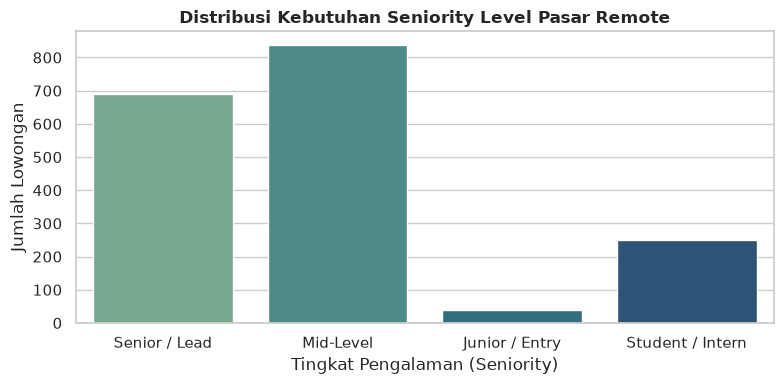

In [9]:
# Grafik 3: Distribusi Seniority Level
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=df, x='seniority', order=['Senior / Lead', 'Mid-Level', 'Junior / Entry', 'Student / Intern'], palette='crest', ax=ax)
ax.set_title("Distribusi Kebutuhan Seniority Level Pasar Remote", fontsize=12, fontweight='bold')
ax.set_xlabel("Tingkat Pengalaman (Seniority)")
ax.set_ylabel("Jumlah Lowongan")
plt.tight_layout()
plt.show()


**Insight Grafik 3**:  
Pasar kerja remote lebih mengutamakan kandidat dengan tingkat pengalaman *Mid-Level* dan *Senior / Lead*. Posisi *Junior / Entry* sangat minim, menunjukkan tantangan bagi lulusan baru untuk langsung bekerja full remote.


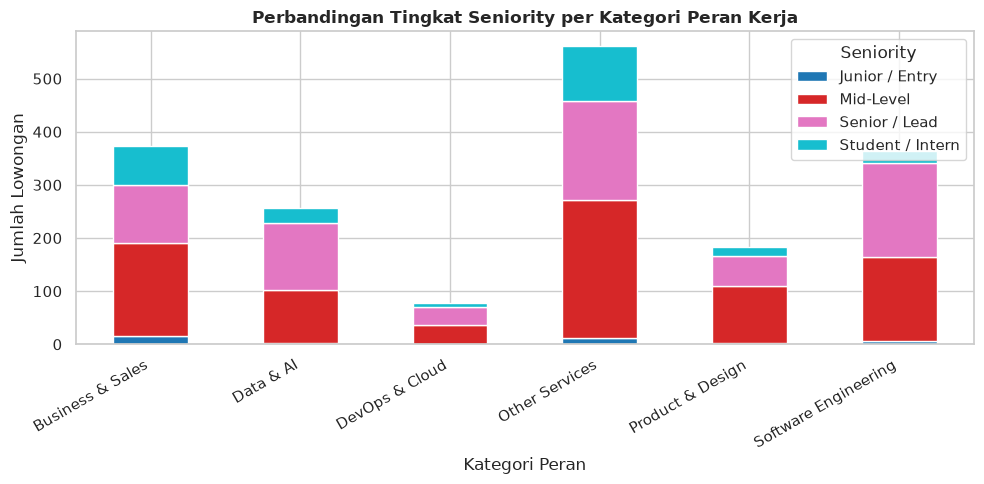

In [10]:
# Grafik 4 (Bivariat): Perbandingan Seniority Level per Kategori Peran
role_seniority = pd.crosstab(df['role_category'], df['seniority'])

fig, ax = plt.subplots(figsize=(10, 5))
role_seniority.plot(kind='bar', stacked=True, colormap='tab10', ax=ax)
ax.set_title("Perbandingan Tingkat Seniority per Kategori Peran Kerja", fontsize=12, fontweight='bold')
ax.set_xlabel("Kategori Peran")
ax.set_ylabel("Jumlah Lowongan")
plt.xticks(rotation=30, ha='right')
plt.legend(title='Seniority')
plt.tight_layout()
plt.show()


**Insight Grafik 4**:  
Pada peran *Software Engineering* dan *DevOps & Cloud*, porsi *Senior / Lead* jauh lebih tinggi dibandingkan peran lain. Sebaliknya, peran *Student / Intern* paling banyak ditemukan pada *Business & Sales*.


## 6. Ringkasan & Kesimpulan

1. **Dataset**: Terdiri dari 1.816 baris lowongan kerja remote global dengan 13 fitur terstruktur.
2. **Kualitas Data**: Missing values pada `location` & `tags` berhasil diimputasi, dan 153 outlier `tags_count` berhasil diidentifikasi.
3. **Temuan Utama**:
   - Bahasa Pemrograman paling diminati: Python, Java, TypeScript, React, JavaScript.
   - Pasar remote global didominasi oleh posisi *Mid-Level* dan *Senior/Lead*.
